In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
import numpy as np

PDM_DIR = os.environ.get('PDM_DIR', '../../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../../..')

from attn_bench.plotting import model_registry
from attn_bench.plotting.utils import SEQ_LEN, smooth
from attn_bench.plotting.data_loading import load_long_individual_sequence, load_packed_chunk_length_hist
from attn_bench.plotting.long_individual_sequence import plot_individual_panel, score_sequences
from attn_bench.plotting.doc_lengths import plot_chunk_length_overlay


def seq_path(model_key, rep):
    return (model_registry.LONG_GUTENBERG_RESULTS_DIR / model_registry.MODELS[model_key] /
            model_registry.LONG_INFERENCE_CONFIG / f"rep_{rep}_individual.jsonl")

# distinguishable colors -- model_registry.MODEL_COLORS groups these by family, too close together here
BUMP_MODEL_COLORS = {
    "full-scf8-scf1": "#0072B2",
    "full-xdl-scf8-scf1": "#E69F00",
    "full-long-docs-scf8-scf1": "#009E73",
    "full-short-docs-scf8-scf1": "#CC79A7",
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from transformers import AutoTokenizer

# Local copy of the cluster's tokenizers/llama-3.2-1b (rsync it down), or the HF hub name
# "meta-llama/Llama-3.2-1B" directly if you have `huggingface-cli login` set up locally --
# either works, AutoTokenizer.from_pretrained accepts both a local path and a hub id.
TOKENIZER_PATH = "meta-llama/Llama-3.2-1B"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)

# Perplexity spikes: long_inference.ipynb follow-up

Per-sequence companion to long_inference.ipynb's aggregate view: investigates the ~3000-token
perplexity bump visible there, first across models/domains/training-doc-lengths (aggregate
NLL, same long-gutenberg-results/long-fineweb-results), then down into individual sequences
(per-sequence NLL records, load_long_individual_sequence) to find and inspect the specific
sequences driving it.

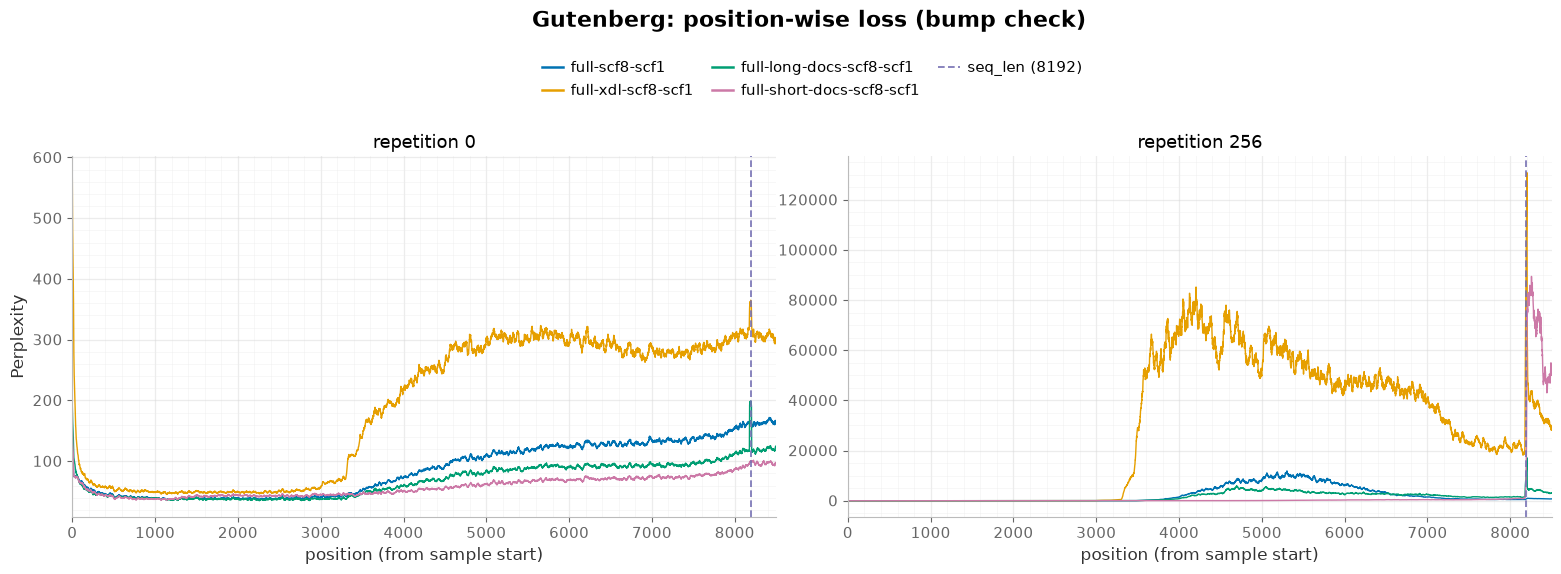

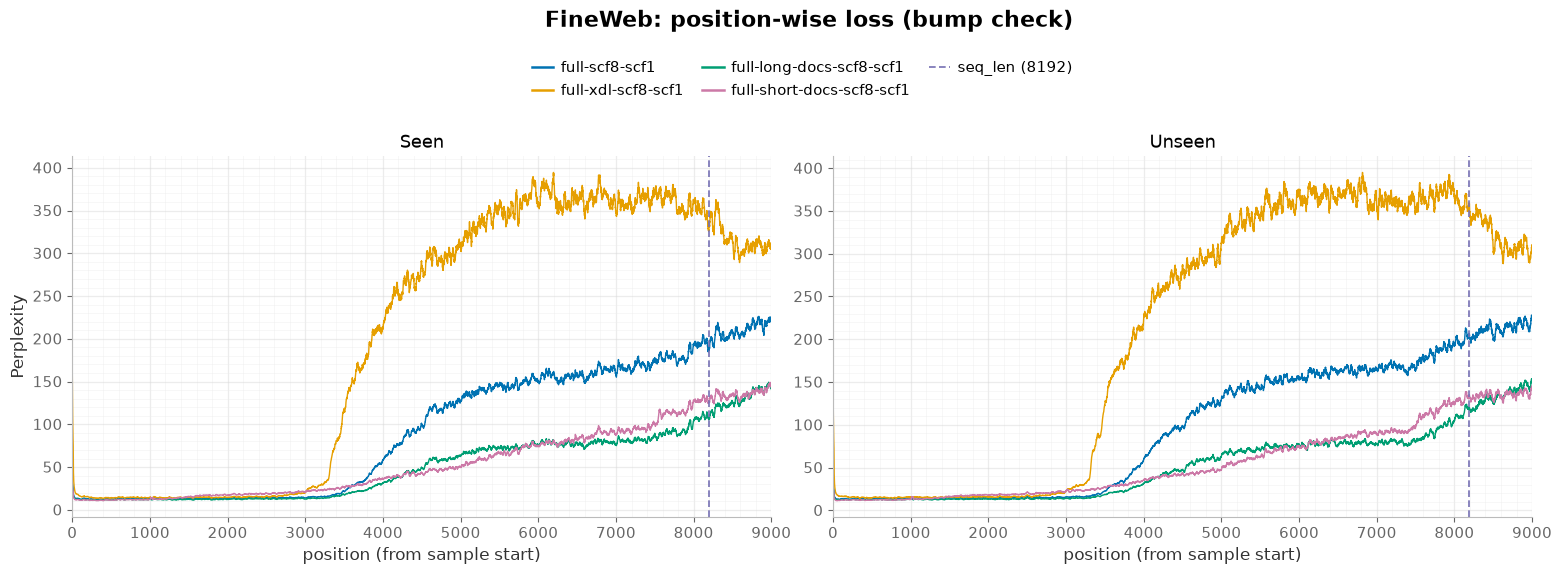

In [5]:
from attn_bench.plotting.data_loading import load_long_inference_nll_grid, load_long_fineweb_inference_nll_grid
from attn_bench.plotting.long_inference import plot_loss_panel

BUMP_MODELS = [
    "full-scf8-scf1",
    "full-xdl-scf8-scf1",
    "full-long-docs-scf8-scf1",
    "full-short-docs-scf8-scf1"
]

gutenberg_grid = load_long_inference_nll_grid([0, 256], models=BUMP_MODELS)
fineweb_grid = load_long_fineweb_inference_nll_grid(models=BUMP_MODELS)

plot_loss_panel(gutenberg_grid, ncols=2, smooth_window=25,
                xmin=0, xmax=8500,
                metric='ppl', sharey=False,
                colors=BUMP_MODEL_COLORS,
                suptitle="Gutenberg: position-wise loss (bump check)",
                vlines={"seq_len": 8192},
                show_random_baseline=False,
                )
plt.show()

plot_loss_panel(fineweb_grid, ncols=2, smooth_window=25, xmax=9000,
                metric='ppl', sharey=False,
                colors=BUMP_MODEL_COLORS,
                bucket_title_fn=str.capitalize,
                suptitle="FineWeb: position-wise loss (bump check)",
                vlines={"seq_len": 8192}
)
plt.show()

### Observations?
Same bump (~3000) on both Gutenberg and FineWeb, unseen/seen, rep 0/256. Possible drivers:
- **xdoc-attention-leak** (`full-xdl` vs `full`): earliest/highest on every corpus -- main driver so far
- **data domain** -- explored below
- **training doc length** (`full-long-docs` vs `full-short-docs`) -- explored below

## Data domain effect: Gutenberg vs Fineweb
 Gutenberg (rep 0, never-trained) vs FineWeb-unseen, on one chart

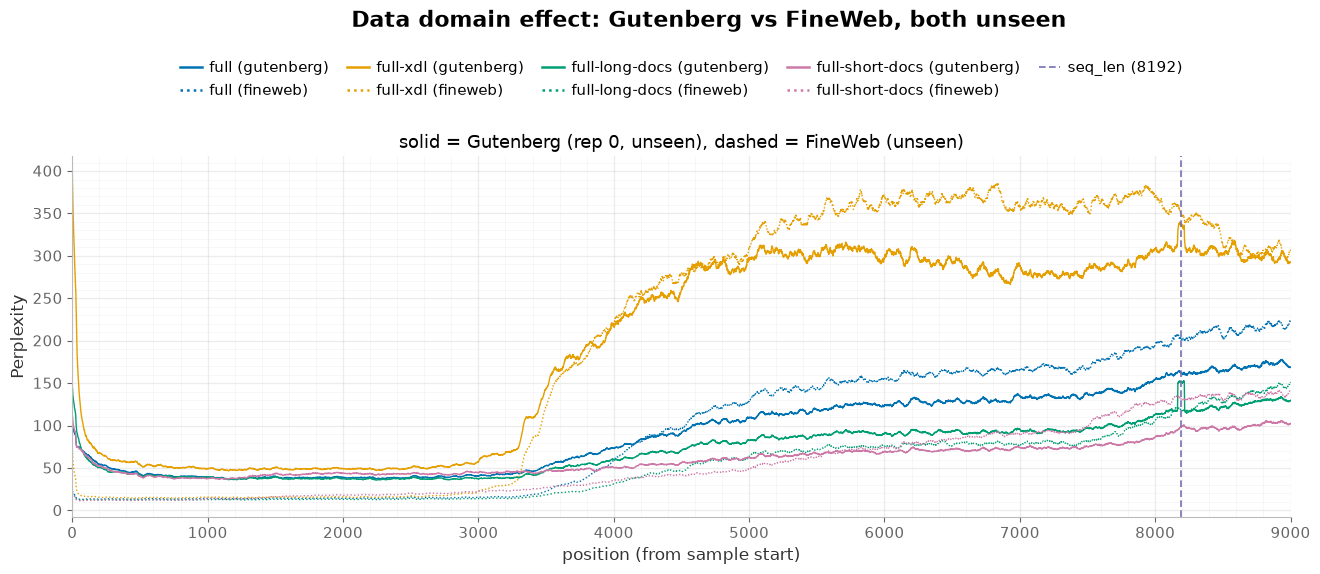

In [26]:
# color = model, linestyle = corpus (solid = Gutenberg, dashed = FineWeb)
DOMAIN_COLORS, DOMAIN_STYLES, domain_grid = {}, {}, {}
for m in BUMP_MODELS:
    if m in gutenberg_grid and 0 in gutenberg_grid[m]:
        lab = f"{m} (gutenberg)"
        domain_grid[lab] = {"unseen": gutenberg_grid[m][0]}
        DOMAIN_COLORS[lab] = BUMP_MODEL_COLORS[m]
        DOMAIN_STYLES[lab] = "-"
    if m in fineweb_grid and "unseen" in fineweb_grid[m]:
        lab = f"{m} (fineweb)"
        domain_grid[lab] = {"unseen": fineweb_grid[m]["unseen"]}
        DOMAIN_COLORS[lab] = BUMP_MODEL_COLORS[m]
        DOMAIN_STYLES[lab] = ":"

plot_loss_panel(domain_grid, ncols=1, cell_w=14, smooth_window=50, xmax=9000,
                metric='ppl', sharey=False,
                colors=DOMAIN_COLORS,
                linestyles=DOMAIN_STYLES,
                bucket_title_fn=lambda b: "solid = Gutenberg (rep 0, unseen), dashed = FineWeb (unseen)",
                suptitle="Data domain effect: Gutenberg vs FineWeb, both unseen",
                vlines={"seq_len": 8192})
plt.show()

### Observations
- Gutenberg higher PPL early (0-3000), Fineweb higher after -- switch at 3800 (full-xdl), 4200 (full), 5600 (full-short-docs), 8200 (full-long-docs)
- bump is sharper for Fineweb (simpler text?)

## Training data length: Short, Long, Mixed
Only long/short are directly comparable since they share the same documents. Mixed is a different set of documents

In [ ]:
LENGTH_MODELS = [
    "full-scf8-scf1",
    "full-long-docs-scf8-scf1",
    "full-short-docs-scf8-scf1"
]  # mixed / long / short training-doc-length
LENGTH_LABELS = {"full-scf8-scf1": "Mixed", "full-long-docs-scf8-scf1": "Long", "full-short-docs-scf8-scf1": "Short"}

LENGTH_CORPUS = "fineweb"  # "gutenberg" (unseen, rep 0) or "fineweb" (unseen)
if LENGTH_CORPUS == "gutenberg":
    length_source = {m: gutenberg_grid[m][0] for m in LENGTH_MODELS
                     if m in gutenberg_grid and 0 in gutenberg_grid[m]}
    length_corpus_title = "Gutenberg, unseen (rep 0)"
else:
    length_source = {m: fineweb_grid[m]["unseen"] for m in LENGTH_MODELS
                     if m in fineweb_grid and "unseen" in fineweb_grid[m]}
    length_corpus_title = "FineWeb, unseen"

length_grid = {LENGTH_LABELS[m]: {"unseen": length_source[m]} for m in length_source}
length_colors = {LENGTH_LABELS[m]: BUMP_MODEL_COLORS[m] for m in LENGTH_MODELS}

# packed-doc mean lengths from training_data.ipynb (full/short similar, long ~8x longer)
LENGTH_VLINES = {
    "mixed packed-doc mean length": 939,
    "short packed-doc mean length": 939,
    "long packed-doc mean length": 4070,
    "seq_len": 8192,
}
LENGTH_VLINE_COLORS = {
    "mixed packed-doc mean length": BUMP_MODEL_COLORS["full-scf8-scf1"],
    "short packed-doc mean length": BUMP_MODEL_COLORS["full-short-docs-scf8-scf1"],
    "long packed-doc mean length": BUMP_MODEL_COLORS["full-long-docs-scf8-scf1"],
    "seq_len": "black",
}

plot_loss_panel(length_grid, ncols=1, cell_w=10, smooth_window=25, xmax=9000,
                metric='ppl', sharey=False,
                colors=length_colors,
                bucket_title_fn=lambda b: length_corpus_title,
                suptitle=f"Training data length effect: Short vs Long ({length_corpus_title})",
                vlines=LENGTH_VLINES, vline_colors=LENGTH_VLINE_COLORS
                )
plt.show()

# dataset length distribution -- filler + gutenberg combined
LENGTH_DATASETS = {
    "fineweb-edu-dedup-160B-datatrove_0.25": "Mixed (dif docs)",
    "fineweb-edu-dedup-160B-datatrove_long_40B": "Long (same docs)",
    "fineweb-edu-dedup-160B-datatrove_long_40B_split1024": "Short (same docs)",
}
LENGTH_CHUNK_COLORS = {
    "Mixed (dif docs)": BUMP_MODEL_COLORS["full-scf8-scf1"],
    "Long (same docs)": BUMP_MODEL_COLORS["full-long-docs-scf8-scf1"],
    "Short (same docs)": BUMP_MODEL_COLORS["full-short-docs-scf8-scf1"],
}

chunk_hists = {name: hist for name, (hist, job_id) in load_packed_chunk_length_hist().items()}
gutenberg_chunk_hist = chunk_hists["gutenberg_rep_1_256"]
length_chunk_hists = {LENGTH_DATASETS[k]: chunk_hists[k] + gutenberg_chunk_hist for k in LENGTH_DATASETS}

plot_chunk_length_overlay(length_chunk_hists, colors=LENGTH_CHUNK_COLORS, seq_len=8192, log_y=False, log_x=False)
plt.show()

### Observations
Bump position roughly matches mean doc length for long/short (same docs) -- not true for Mixed (different docs, different distribution)

# Exploring individual sequences

## Quantifying perplexity spikes
Step-detection stats on `full`: how often the perplexity spike happens, and where.

In [ ]:
# step(x) = after-window mean minus before-window mean -- catches a sudden, sustained jump directly
SEARCH_RANGE = (1500, 5000)   # wide enough to not assume every sequence's jump sits at 3000
SMOOTH_WINDOW = 15            # kill single-token noise, not the step shape
STEP_WINDOW = 150             # before/after window for the step statistic
STEP_THRESH = 0.3             # nats; step_size above this counts as "has a step"

MODELS_TO_LOAD = ["full-scf8-scf1", "full-xdl-scf8-scf1", "full-short-docs-scf8-scf1", "full-long-docs-scf8-scf1"]   # models compared in the plots below

records_by_rep = {}
for rep in (0, 256):
    records_by_rep[rep] = {
        lab: load_long_individual_sequence(seq_path(lab, rep))
        for lab in MODELS_TO_LOAD
    }


In [ ]:
def rolling_window_mean(x, window):
    # roll[i] = mean(x[i:i+window]), for i = 0 .. len(x) - window
    csum = np.cumsum(np.insert(x, 0, 0.0))
    return (csum[window:] - csum[:-window]) / window

def find_step(nll, search_range, smooth_window, step_window):
    sm = smooth(np.array(nll, dtype=float), smooth_window)
    roll = rolling_window_mean(sm, step_window)
    lo = max(search_range[0], step_window)
    hi = min(search_range[1], len(sm) - step_window)
    if hi <= lo:
        return None
    xs = np.arange(lo, hi)
    steps = roll[xs] - roll[xs - step_window]
    i = np.argmax(steps)
    return int(xs[i]), float(steps[i])

# scoped to "full-scf8-scf1" only -- that's what this diagnostic was built for
def is_long_enough(seq_id, records):
    return records["full-scf8-scf1"]["length"] >= SEARCH_RANGE[1]

def step_score(seq_id, records):
    return find_step(records["full-scf8-scf1"]["nll"], SEARCH_RANGE, SMOOTH_WINDOW, STEP_WINDOW)

for rep in (0, 256):
    scores = score_sequences(records_by_rep[rep], filter_fns=[is_long_enough], sort_key=step_score)
    scores = {sid: s for sid, s in scores.items() if s is not None}
    positions = np.array([s[0] for s in scores.values()])
    sizes = np.array([s[1] for s in scores.values()])
    has_step = sizes > STEP_THRESH

    print(f"rep={rep}: {len(sizes)}/{len(records_by_rep[rep]['full-scf8-scf1'])} sequences long enough to search")
    print(f"  step size: min={sizes.min():.2f}  median={np.median(sizes):.2f}  "
          f"mean={sizes.mean():.2f}  max={sizes.max():.2f}")
    print(f"  step_size > {STEP_THRESH}: {has_step.sum()}/{len(sizes)} sequences "
          f"({100 * has_step.mean():.0f}%)")
    if has_step.any():
        step_pos = positions[has_step]
        print(f"  step position (of those with a step): "
              f"min={step_pos.min()}  median={np.median(step_pos):.0f}  max={step_pos.max()}")
    print()

## Heuristics
Rank sequences by different divergence heuristics between `full-long-docs` and `full-short-docs`, then inspect the top hits.

In [ ]:
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import (
    load_long_individual_sequence,
    list_long_individual_sequence_ids,
)
from attn_bench.plotting.long_individual_sequence import plot_individual_panel, filter_sequences
from attn_bench.plotting.utils import smooth

LONG_SPLIT_MODELS = ["full-long-docs-scf8-scf1", "full-short-docs-scf8-scf1"]

def seq_path(model_key, rep):
    return (model_registry.LONG_GUTENBERG_RESULTS_DIR / model_registry.MODELS[model_key] /
            model_registry.LONG_INFERENCE_CONFIG / f"rep_{rep}_individual.jsonl")

### Squared-diff heuristic: biggest overall divergence

Top-10 sequences ranked by mean squared NLL difference between `full-long-docs` and
`full-short-docs` over positions [0, SEQ_LEN), computed on smoothed curves (avoids ranking
on noise the plot would smooth away anyway). Ranked separately per rep.

In [ ]:
N_TOP = 10
POSITION_MIN = 0
POSITION_MAX = SEQ_LEN   # 8192: only the trained/memorized region, not the extrapolation past it
RANK_SMOOTH_WINDOW = 50  # match the plot's smooth_window below

def squared_diff_key(a_label, b_label, position_min=0, position_max=None, smooth_window=0):
    """sort_key: mean squared NLL difference between a_label/b_label over [position_min,
    position_max), smoothed to match the plot."""
    def key(seq_id, records):
        a = np.asarray(records[a_label]["nll"][position_min:position_max])
        b = np.asarray(records[b_label]["nll"][position_min:position_max])
        if smooth_window:
            a, b = smooth(a, smooth_window), smooth(b, smooth_window)
        return float(np.mean((a - b) ** 2))
    return key

# Find pass: rank + reload only the top sequences, once -- the plotting cell below can be
# re-run separately against the already-loaded records.
long_split_top_by_rep = {}
for rep in (0, 256):
    paths = {m: seq_path(m, rep) for m in LONG_SPLIT_MODELS}
    top_ids, records, scores = filter_sequences(
        paths, filter_fns=[],
        sort_key=squared_diff_key(*LONG_SPLIT_MODELS, POSITION_MIN, POSITION_MAX, RANK_SMOOTH_WINDOW),
        n_top=N_TOP,
    )
    long_split_top_by_rep[rep] = {"top_ids": top_ids, "records": records}

In [ ]:
# Plotting only -- re-run with different params without repeating the find pass above.
REP = 0
top = long_split_top_by_rep[REP]

fig = plot_individual_panel(top["records"], top["top_ids"], x_range=(1020, 1100), ncols=2,
                      tokenizer=tokenizer, max_tokens_for_labels=100, smooth_window=50,
                      show_unsmoothed=True, colors=model_registry.MODEL_COLORS, show_rank=False,
                      smooth_window_true_rank=0, sharey=True, metric="nll", show_random_baseline=True,
                      suptitle=f"rep={REP}: top-{N_TOP} biggest long vs split-1024 divergences "
                               f"(mean squared NLL diff over positions {POSITION_MIN}-{POSITION_MAX})")
plt.show()

### Individual sequences — biggest single-position long vs split-1024 jump

Same models, different metric: max pointwise |NLL diff| at any single position (not
averaged), on raw NLL -- smoothing would blunt the peak this looks for.

In [ ]:
N_TOP_PEAK = 10

def max_abs_diff_key(a_label, b_label, position_min=0, position_max=None):
    """sort_key: single biggest pointwise |NLL diff| between a_label/b_label over
    [position_min, position_max), on raw NLL."""
    def key(seq_id, records):
        a = np.asarray(records[a_label]["nll"][position_min:position_max])
        b = np.asarray(records[b_label]["nll"][position_min:position_max])
        return float(np.max(np.abs(a - b)))
    return key

long_split_peak_by_rep = {}
for rep in (0, 256):
    paths = {m: seq_path(m, rep) for m in LONG_SPLIT_MODELS}
    top_ids, records, scores = filter_sequences(
        paths, filter_fns=[],
        sort_key=max_abs_diff_key(*LONG_SPLIT_MODELS, POSITION_MIN, POSITION_MAX),
        n_top=N_TOP_PEAK,
    )
    # peak position for the winners only -- cheap, they're already loaded
    peaks = {}
    for sid in top_ids:
        a = np.asarray(records[LONG_SPLIT_MODELS[0]][sid]["nll"][POSITION_MIN:POSITION_MAX])
        b = np.asarray(records[LONG_SPLIT_MODELS[1]][sid]["nll"][POSITION_MIN:POSITION_MAX])
        i = int(np.argmax(np.abs(a - b)))
        peaks[sid] = (scores[sid], POSITION_MIN + i)
    long_split_peak_by_rep[rep] = {"top_ids": top_ids, "records": records, "peaks": peaks}

for rep, top in long_split_peak_by_rep.items():
    print(f"rep={rep}: top peak |diff| (position)")
    for sid in top["top_ids"]:
        val, pos = top["peaks"][sid]
        print(f"  {sid:>8}: {val:.2f} nats @ position {pos}")

window too wide for token labels (8692 > 100 positions) -- plotting without the token strip.


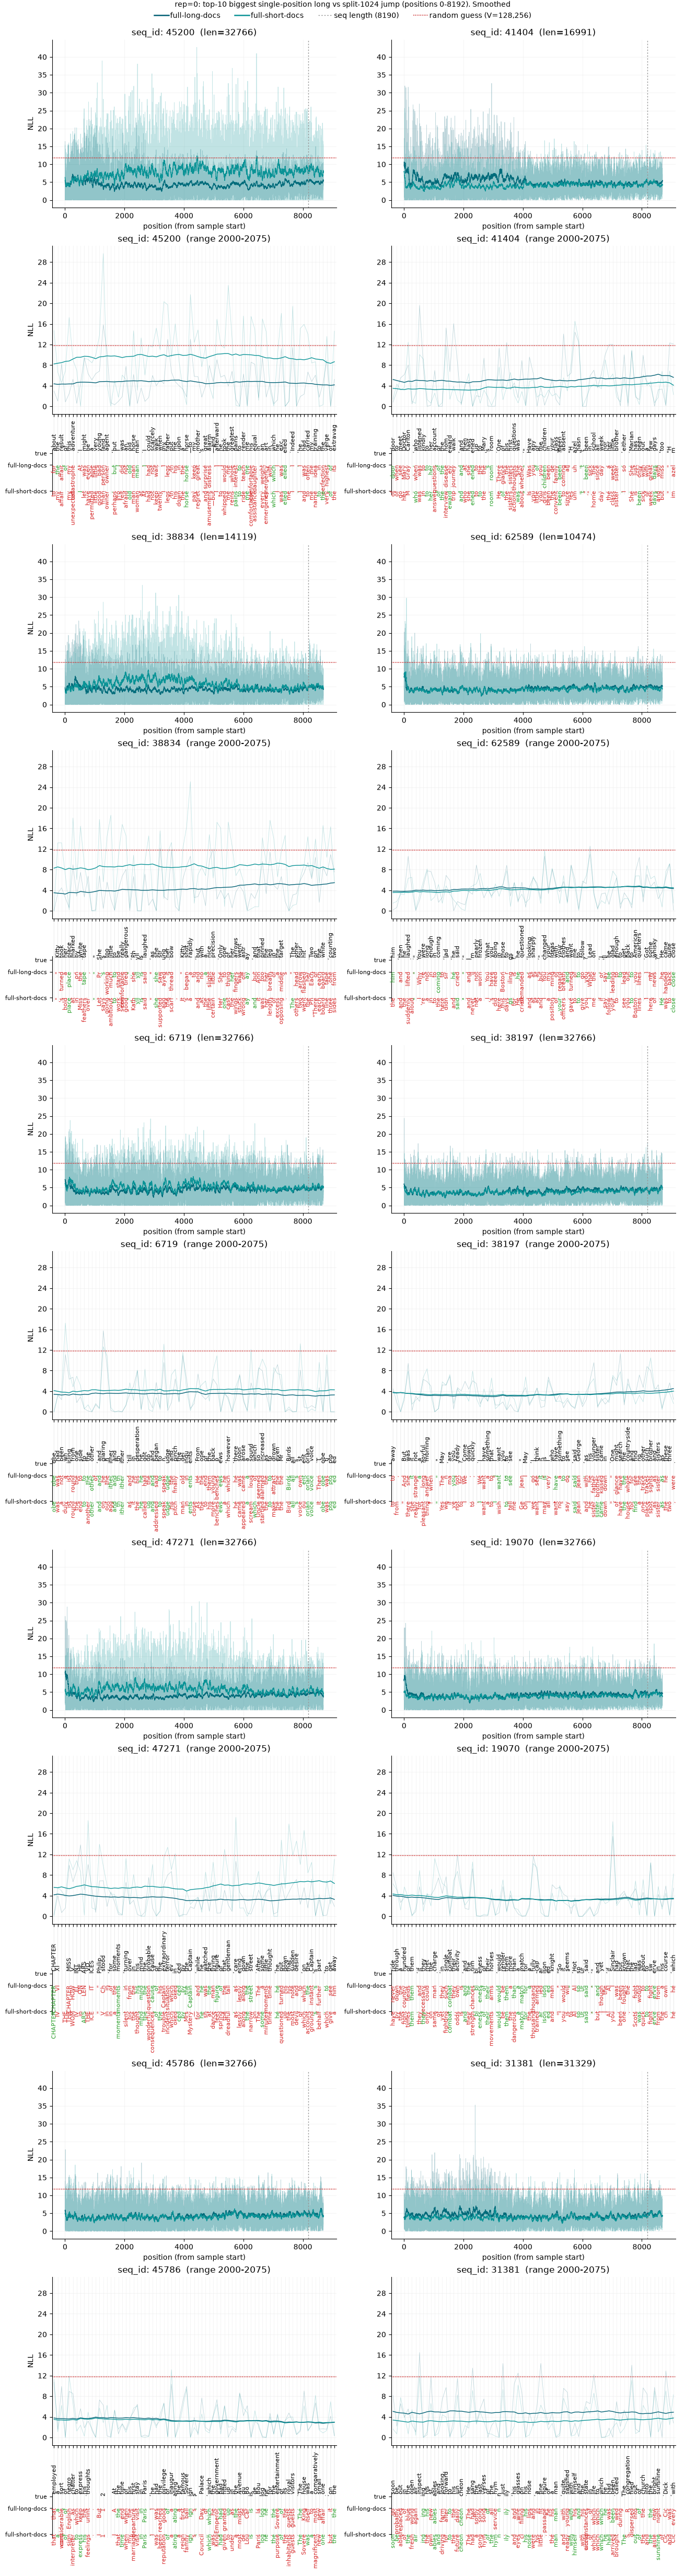

In [84]:
# Plotting only -- re-run with different params without repeating the find pass above.
REP = 0
top = long_split_peak_by_rep[REP]

fig = plot_individual_panel(top["records"], top["top_ids"], x_range=(0, SEQ_LEN + 500), ncols=2,
                      tokenizer=tokenizer, max_tokens_for_labels=100, smooth_window=50,
                      show_unsmoothed=True, colors=model_registry.MODEL_COLORS, show_rank=False,
                      smooth_window_true_rank=0, sharey=True, metric="nll", show_random_baseline=True,
                      zoom_range=(2000, 2075),
                      suptitle=f"rep={REP}: top-{N_TOP_PEAK} biggest single-position long vs "
                               f"split-1024 jump (positions {POSITION_MIN}-{POSITION_MAX}). Smoothed")
plt.show()

### Individual sequences — 2 random + 2 chosen (45200, 41404)

Sanity check: 2 random `seq_id`s + the top-2 peak-diff sequences from above, same layout,
so the ranked ones can be compared against an unbiased sample.

In [ ]:
import random

REP = 0
CHOSEN_IDS = ["45200", "41404"]
paths = {m: seq_path(m, REP) for m in LONG_SPLIT_MODELS}

# cheap regex scan, not a full per-sequence parse -- safe for a genuinely random sample
all_ids = list_long_individual_sequence_ids(paths["full-long-docs-scf8-scf1"])
random_ids = random.sample(all_ids, 2)
combined_ids = random_ids + CHOSEN_IDS
print("random:", random_ids, " chosen:", CHOSEN_IDS)

combined_records = {m: load_long_individual_sequence(p, seq_ids=set(combined_ids)) for m, p in paths.items()}

fig = plot_individual_panel(combined_records, combined_ids, x_range=(0, SEQ_LEN + 500), ncols=2,
                      tokenizer=tokenizer, max_tokens_for_labels=100, smooth_window=50,
                      show_unsmoothed=True, colors=model_registry.MODEL_COLORS, show_rank=False,
                      smooth_window_true_rank=0, sharey=True, metric="nll", show_random_baseline=True,
                      zoom_range=(2000, 2075), suptitle=f"rep={REP}: 2 random + 2 chosen (45200, 41404)")
plt.show()